In [34]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Names and PRN for all group members:
- Name: Satyam Prajapati
- PRN:  250840128028
- Date: 22/11/2025

# Image Processing with Neural Network
## A07: Group Assignment


##  Convolutional Neural Network (CNN)

- Flowers Dataset


In [35]:
###-----------------
### Import Libraries
###-----------------
import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import accuracy_score,classification_report, f1_score
from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix,fn_plot_label


%matplotlib inline

In [36]:
###----------------------
### Some basic parameters
###----------------------

# inpDir = Path('.') # location where input data is stored
# outDir = Path('.') # location to store outputs
subDir = 'flower_photos' # location of the images
modelDir = Path('../models') # location to save model files
valDir = 'valid_flowers' # location related to this dataset
altName = 'base_flowers' # Model file name for this alternative

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE)


EPOCHS = 100   # number of cycles to run
ALPHA = 0.001
BATCH_SIZE = 32
TEST_SIZE = 0.2
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Transformations
# flipping
FLIP_MODE = "horizontal_and_vertical"
# Rotation
ROTATION_FACTOR = (-0.1, 0.1)
# filling mode
FILL_MODE = 'nearest'


## Early Stopping
ES_PATIENCE = 20 # if performance does not improve stop
# Learning rates
LR_PATIENCE = 10 # if performace is not improving reduce alpha
LR_FACTOR = 0.5 # rate of reduction of alpha


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,8),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

## Basic Hygiene

In [37]:
###------------------
### Memory Management
###------------------

physical_devices = tf.config.list_physical_devices('GPU')

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print (physical_devices)
else:
    print ('Error: No GPU device found')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Helper Functions
**Note** all helper functions have been moved to util.helper

## Load Dataset

Images are under flower_photos

     |- daisy
     |- dandelion
     |- roses
     |- sunflowers
     |- tulips

In [38]:
# '''
#     For reading from web link
# '''

# import pathlib
# dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
# data_dir = tf.keras.utils.get_file(origin=dataset_url,
#                                   fname='flower_photos',
#                                   untar=True)
# data_dir = pathlib.Path(data_dir) / 'flower_photos'
# # '''
# #     For reading from local directory
# # '''
# data_dir = os.path.join('/content/flower_photos')

In [39]:
import tensorflow as tf
import pathlib
import os

# Download and extract dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(
    fname='flower_photos',
    origin=dataset_url,
    untar=True
)

# Convert to pathlib Path object for easy path operations
data_dir = pathlib.Path(data_dir) / 'flower_photos'
print(f"Dataset downloaded and extracted to: {data_dir}")

# Example: load dataset using image_dataset_from_directory
dataset = tf.keras.utils.image_dataset_from_directory(str(data_dir))

# If you want to access the images later, you can list files like this:
image_files = list(data_dir.glob('*/*.jpg'))
print(f"Number of images: {len(image_files)}")

# If you want to save or reference this directory within Colab session use this path:
print(f"Local directory path in Colab: {data_dir}")


Dataset downloaded and extracted to: /root/.keras/datasets/flower_photos/flower_photos
Found 3670 files belonging to 5 classes.
Number of images: 3670
Local directory path in Colab: /root/.keras/datasets/flower_photos/flower_photos


In [40]:
data_dir

PosixPath('/root/.keras/datasets/flower_photos/flower_photos')

In [41]:
# list content of data_dir
os.listdir(data_dir)

['sunflowers', 'roses', 'LICENSE.txt', 'daisy', 'dandelion', 'tulips']

In [42]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='training',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='validation',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


### Is it picking the class names?

In [43]:
class_names = train_ds.class_names
num_classes = len(class_names)
print('total ', num_classes, class_names)

total  5 ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Verify the data

To verify that the dataset looks correct, let's plot the first batch from the training set and display the class name below each image.


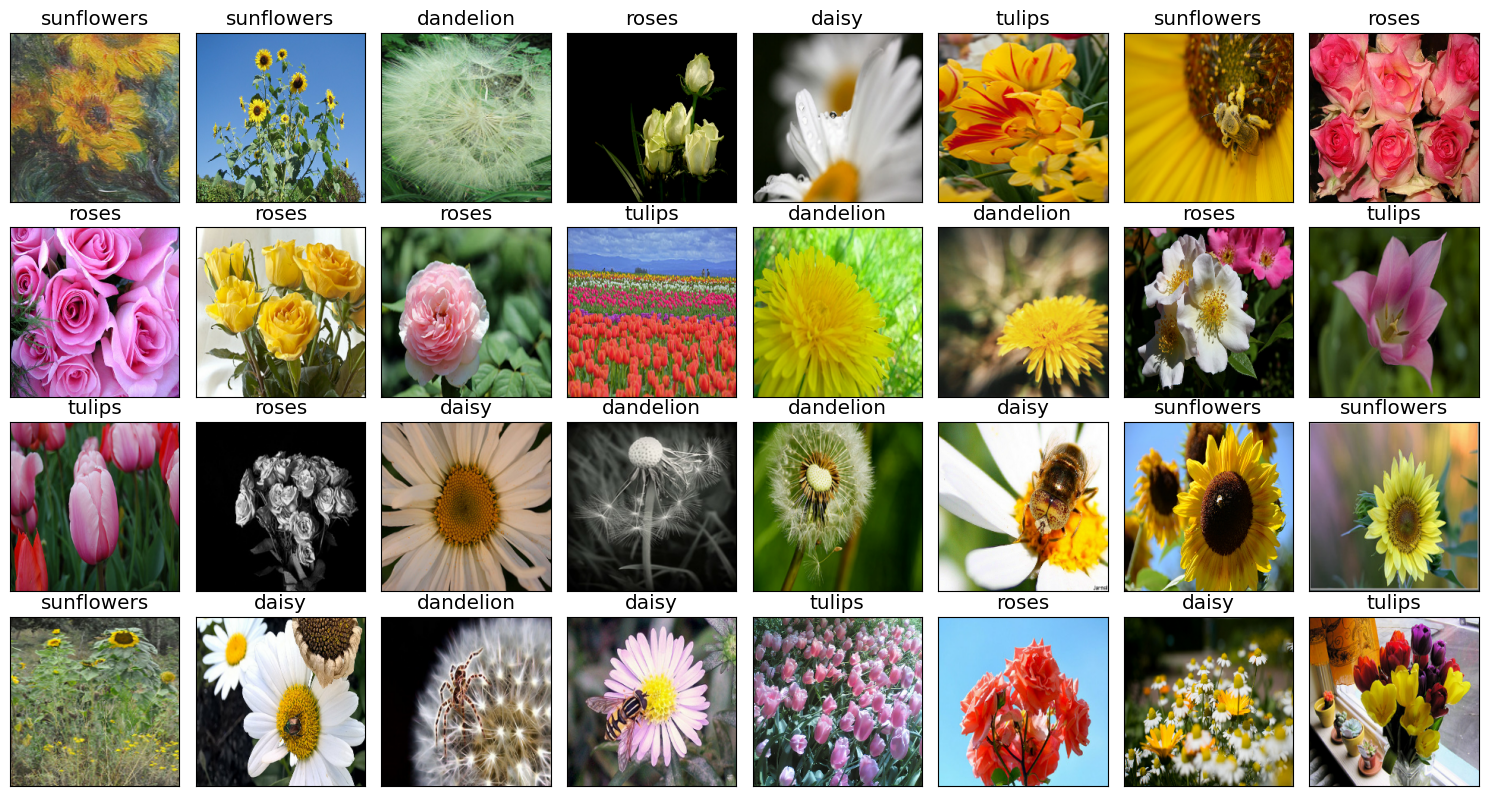

In [44]:
# set figure size
fig = plt.figure()  # figure size in inches with default params

# Adjust the subplot layout parameters.
fig.subplots_adjust(left=0., # as a fraction of the figure width
                    right=1., # use full width, as a fraction of the figure width
                    bottom=0., # as a fraction of the figure height
                    top=1., # as a fraction of the figure height
                    hspace=0.05, # as a fraction of the average Axes height
                    wspace=0.05) # width of the padding between subplots

# take one batch of the dataset
for images, labels in train_ds.take(1):

    # iterate through the batch
    for i in range(BATCH_SIZE):

        # add a subplot
        ax = fig.add_subplot( BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure

        # image_size may have converted these images to float
        ax.imshow(images[i].numpy().astype("uint8"))

        # display class in the title
        ax.set_title(class_names[labels[i]])

# fit the subplot(s) in to the figure area
plt.tight_layout()

# display all open images
plt.show()

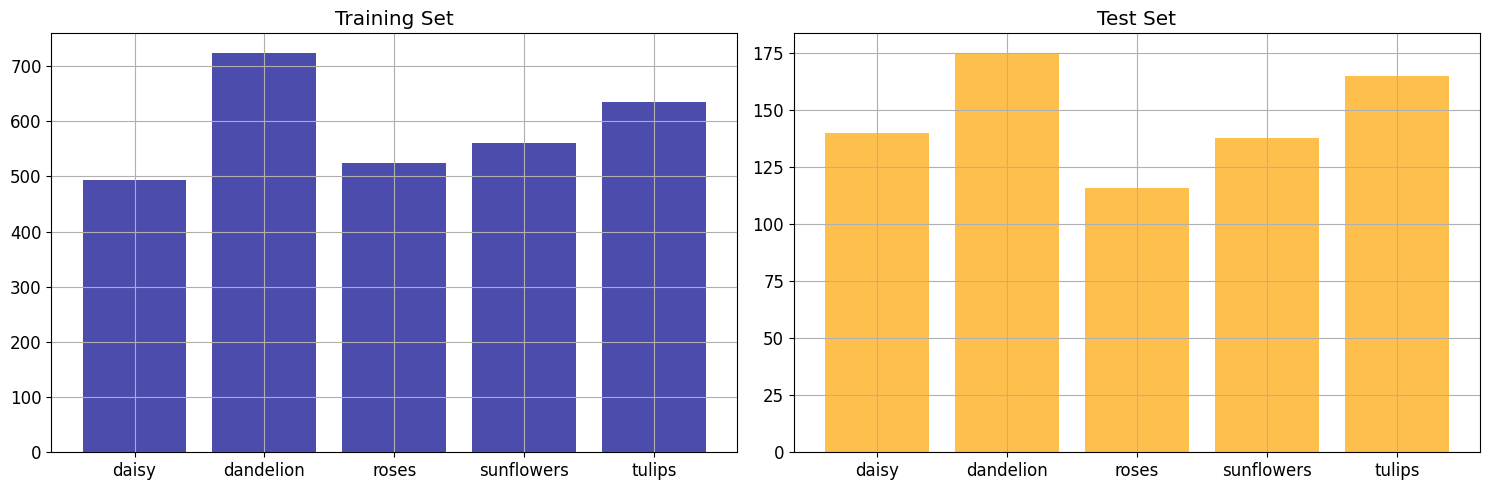

In [45]:
# how many examples in each of the class
fn_plot_label(train_ds, test_ds)

In [46]:
images[0].shape

TensorShape([224, 224, 3])

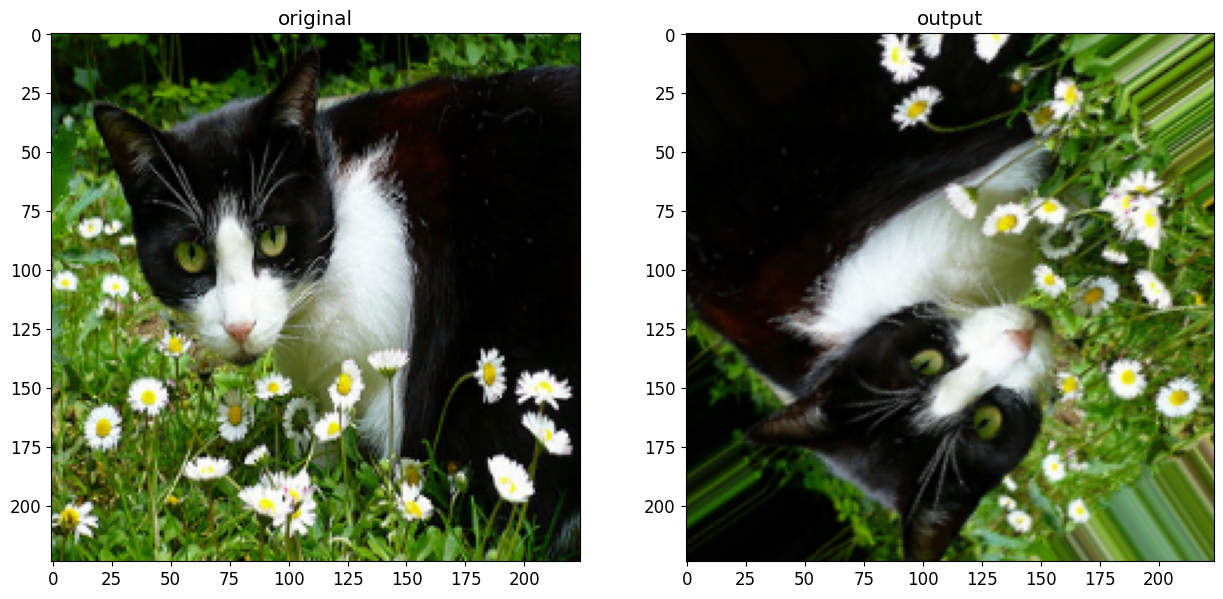

In [47]:
# layer = tf.keras.layers.RandomZoom(height_factor = (-0.2,0.2),
#                              width_factor = (-0.2,0.2))

layer = tf.keras.layers.RandomRotation((-0.5,0.5),fill_mode='nearest')

plt.figure()
img_num = 0
for images,labels in train_ds.take(1):
    out_images = layer(images)
plt.subplot(1,2,1)
plt.title('original')
plt.imshow(images[img_num].numpy().astype('uint16'))

plt.subplot(1,2,2)
plt.title('output')
plt.imshow(out_images[img_num].numpy().astype('uint16'))

<h1>BUILD MODEL</h1>

In [48]:
input_shape = [IMG_HEIGHT,IMG_WIDTH,3]

In [49]:
def build_model(input_shape, num_classes):



    dor1 = 0.1
    dor2 = 0.2
    dor3 = 0.3
    dor4 = 0.4
    dor5 = 0.5
    dor6 = 0.5
    dor7 = 0.5


    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape = input_shape))
    model.add(tf.keras.layers.Rescaling(1./255))


    #data augmenttaion
    model.add(tf.keras.layers.RandomFlip("horizontal"))
    model.add(tf.keras.layers.RandomRotation(0.1)) # Up to +/- 10% rotation
    model.add(tf.keras.layers.RandomZoom(0.2))    # Zoom in by up to 20%


    #set 1
    model.add(tf.keras.layers.Conv2D(32, (3,3)))
    model.add(tf.keras.layers.BatchNormalization())# 222 x 222 x 32
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 111 x 111 x32
    # model.add(tf.keras.layers.Dropout(dor1))

    #set 2
    model.add(tf.keras.layers.Conv2D(64, (3,3)))
    model.add(tf.keras.layers.BatchNormalization())# 109 x 109 x 64

    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D())# 54 x 54 x 64
    # model.add(tf.keras.layers.Dropout(dor2))


    #set 3
    model.add(tf.keras.layers.Conv2D(128, (3,3)))
    model.add(tf.keras.layers.BatchNormalization()) # 52 x 52 x 128
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 26 x 26 x 128
    # model.add(tf.keras.layers.Dropout(dor3))


    #set 4
    model.add(tf.keras.layers.Conv2D(256, (3,3)))
    model.add(tf.keras.layers.BatchNormalization())# 24 x 24 x 256
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 12 x 12 x 256
    # model.add(tf.keras.layers.Dropout(dor4))


    #set 5
    model.add(tf.keras.layers.Conv2D(512, (3,3)))
    model.add(tf.keras.layers.BatchNormalization())# 10 x 10 x 512
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D())# 3 x 3 x 1024
    # model.add(tf.keras.layers.Dropout(dor5))


    # #set 6
    # model.add(tf.keras.layers.Conv2D(1024, (3,3))
    # model.add(tf.keras.layers.BatchNormalization())) # 3 x 3 x 1024
    # model.add(tf.keras.layers.ReLU())
    # model.add(tf.keras.layers.Dropout(dor6))
    model.add(tf.keras.layers.Flatten()) # 9216


    # Head
    model.add(tf.keras.layers.Dense(512)) # 1024
    model.add(tf.keras.layers.BatchNormalization())# 10 x 10 x 512
    model.add(tf.keras.layers.ReLU())
    # model.add(tf.keras.layers.Dropout(dor7))



    #Output
    model.add(tf.keras.layers.Dense(num_classes))

    return model
model = build_model(input_shape,num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 109, 109, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 512)    │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 8,131,269 (31.02 MB)

 Trainable params: 8,128,261 (31.01 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [50]:
#call backs
PATIENCE = 20
LR_FACTOR =0.1
LR_PATIENCE = 5
MIN_LR = 1e-6

es_callback = tf.keras.callbacks.EarlyStopping(monitor= 'val_loss',
                                              patience=PATIENCE,
                                              verbose = 1,
                                              restore_best_weights=True,
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
   monitor='val_loss',
    factor= LR_FACTOR,
    patience = LR_PATIENCE,
    verbose = 1,
    mode = 'auto',
    min_lr=MIN_LR
)



In [51]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA)
model.compile(optimizer = optimizer,
             loss = loss_fn,

             metrics = ['accuracy'])

In [52]:
history = model.fit(train_ds,
         validation_data=test_ds,
         epochs= EPOCHS,
         callbacks=[es_callback,lr_callback])

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.5033 - loss: 1.5627 - val_accuracy: 0.2384 - val_loss: 2.2451 - learning_rate: 0.0010
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.6402 - loss: 0.9320 - val_accuracy: 0.2384 - val_loss: 2.6415 - learning_rate: 0.0010
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 151ms/step - accuracy: 0.6579 - loss: 0.8847 - val_accuracy: 0.3392 - val_loss: 1.9669 - learning_rate: 0.0010
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.7119 - loss: 0.7870 - val_accuracy: 0.5817 - val_loss: 1.1441 - learning_rate: 0.0010
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - accuracy: 0.7102 - loss: 0.7333 - val_accuracy: 0.4986 - val_loss: 1.7654 - learning_rate: 0.0010
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.7416 - loss: 0.6993 - val_accuracy: 0.6240 - val_loss: 1.0971 - learning_rate: 0.0010
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - accuracy: 0.7392 - l

### Reload best Weights for evaluation

### Evaluate the model

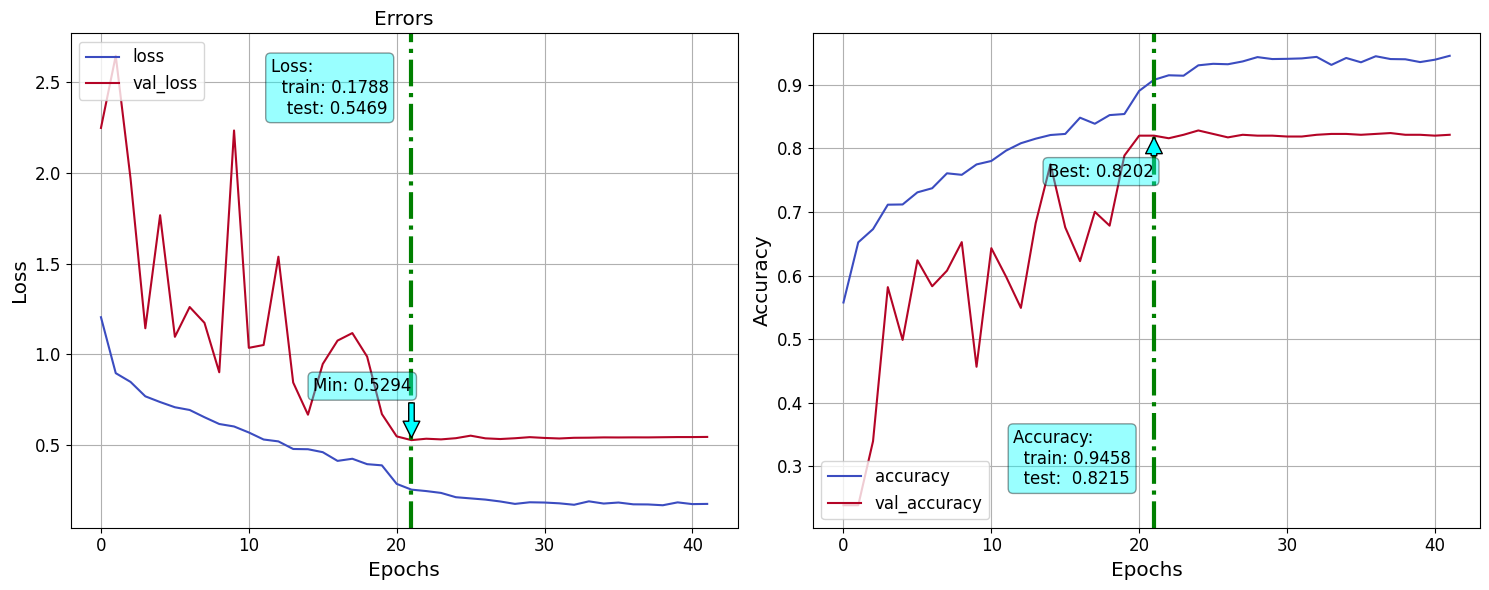

In [53]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [54]:
y_true,y_pred = [],[]
for feat,lbls in train_ds:
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis = 1))
print(f'Accuracy : {accuracy_score(y_true,y_pred)}')
print(f'Accuracy : {classification_report(y_true,y_pred)}')

Accuracy : 0.9230245231607629
Accuracy :               precision    recall  f1-score   support

           0       0.94      0.94      0.94       493
           1       0.92      0.95      0.93       723
           2       0.88      0.88      0.88       525
           3       0.96      0.94      0.95       561
           4       0.92      0.90      0.91       634

    accuracy                           0.92      2936
   macro avg       0.92      0.92      0.92      2936
weighted avg       0.92      0.92      0.92      2936



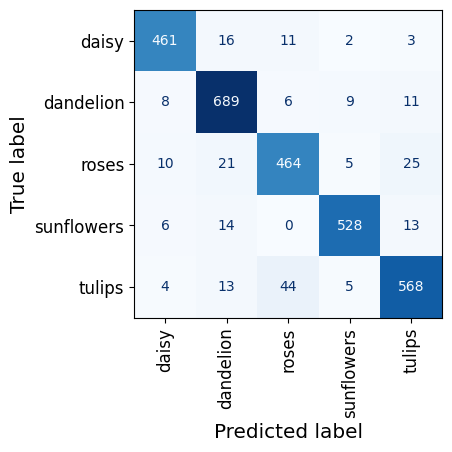

In [55]:
fn_plot_confusion_matrix(y_true, y_pred, class_names)

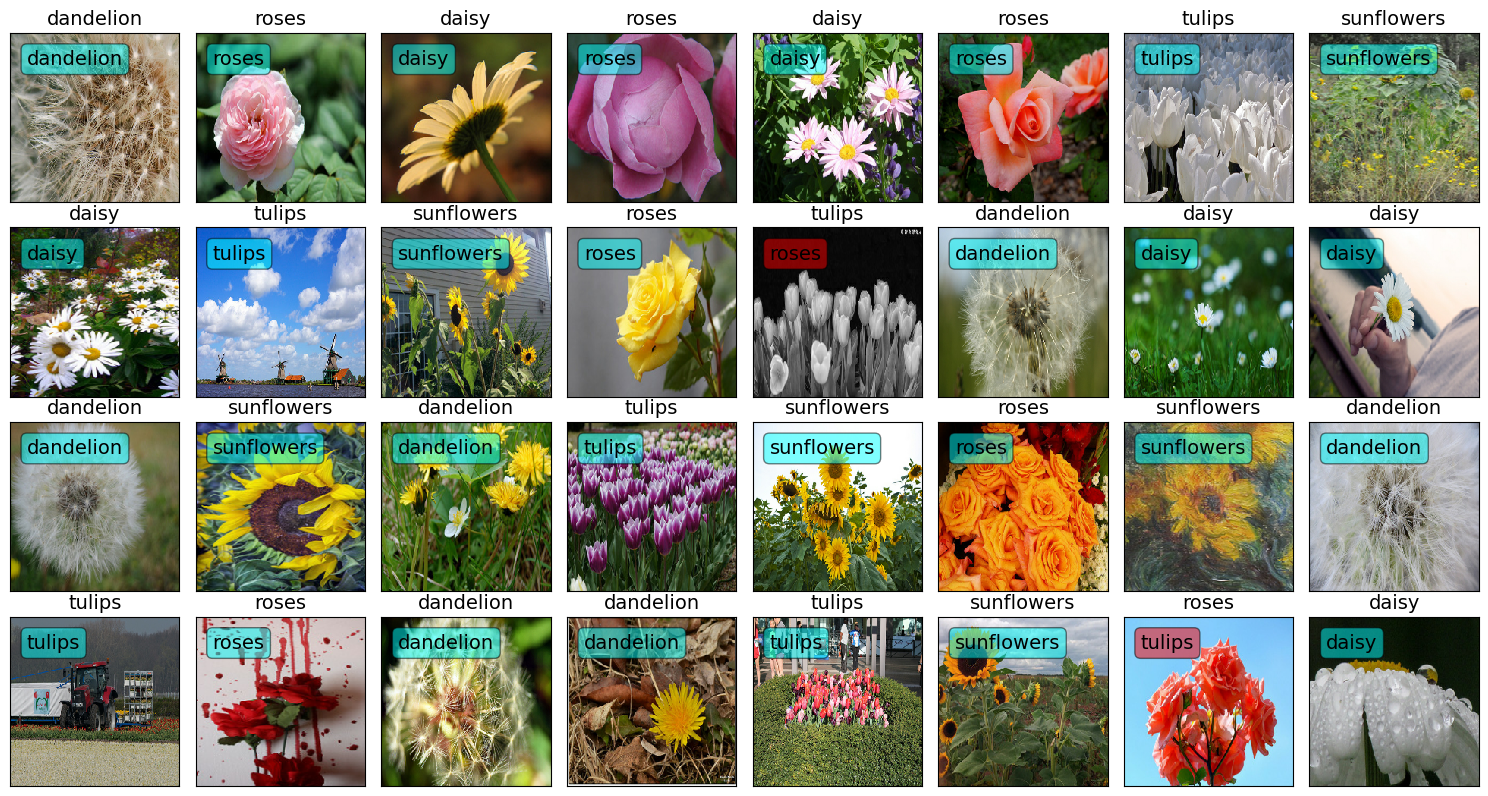

In [56]:
fig = plt.figure()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

i=0
for images, labels in train_ds.take(1):
    yhat = model(images).numpy()
    y_pred = yhat.argmax(axis=1)
    for i in range(BATCH_SIZE):
        ax = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[])
        ax.grid(False)
        color = 'cyan'
        if y_pred[i] != labels[i]:
            color = 'red'
        props = dict(boxstyle = 'round',facecolor = color,alpha = 0.5)
        ax.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary, interpolation='nearest')
        # ax.text(2,4, str(labels[i].numpy()), color='b', fontsize=14)
        # ax.text(10,25, class_names[labels[i].numpy()], color='r', fontsize=10)
        ax.text(0.1,0.90,class_names[y_pred[i]],bbox = props,
               verticalalignment = 'top',
               transform = ax.transAxes,fontsize = 14)
        ax.set_title(class_names[labels[i].numpy()],fontsize = 14)
plt.tight_layout()
plt.show()

## Validate on the validation set

In [57]:
# loss, acc = model.evaluate(valid_ds)

# print('Accuracy score on Validation Data : {:.3f}%'.format( acc*100))

In [58]:
y_true,y_pred = [],[]
for feat,lbls in test_ds:
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis = 1))
print(f'Accuracy : {accuracy_score(y_true,y_pred)}')
print(f'Accuracy : {classification_report(y_true,y_pred)}')

Accuracy : 0.7929155313351499
Accuracy :               precision    recall  f1-score   support

           0       0.93      0.77      0.84       140
           1       0.81      0.87      0.84       175
           2       0.60      0.67      0.64       116
           3       0.87      0.88      0.87       138
           4       0.76      0.75      0.75       165

    accuracy                           0.79       734
   macro avg       0.79      0.79      0.79       734
weighted avg       0.80      0.79      0.79       734



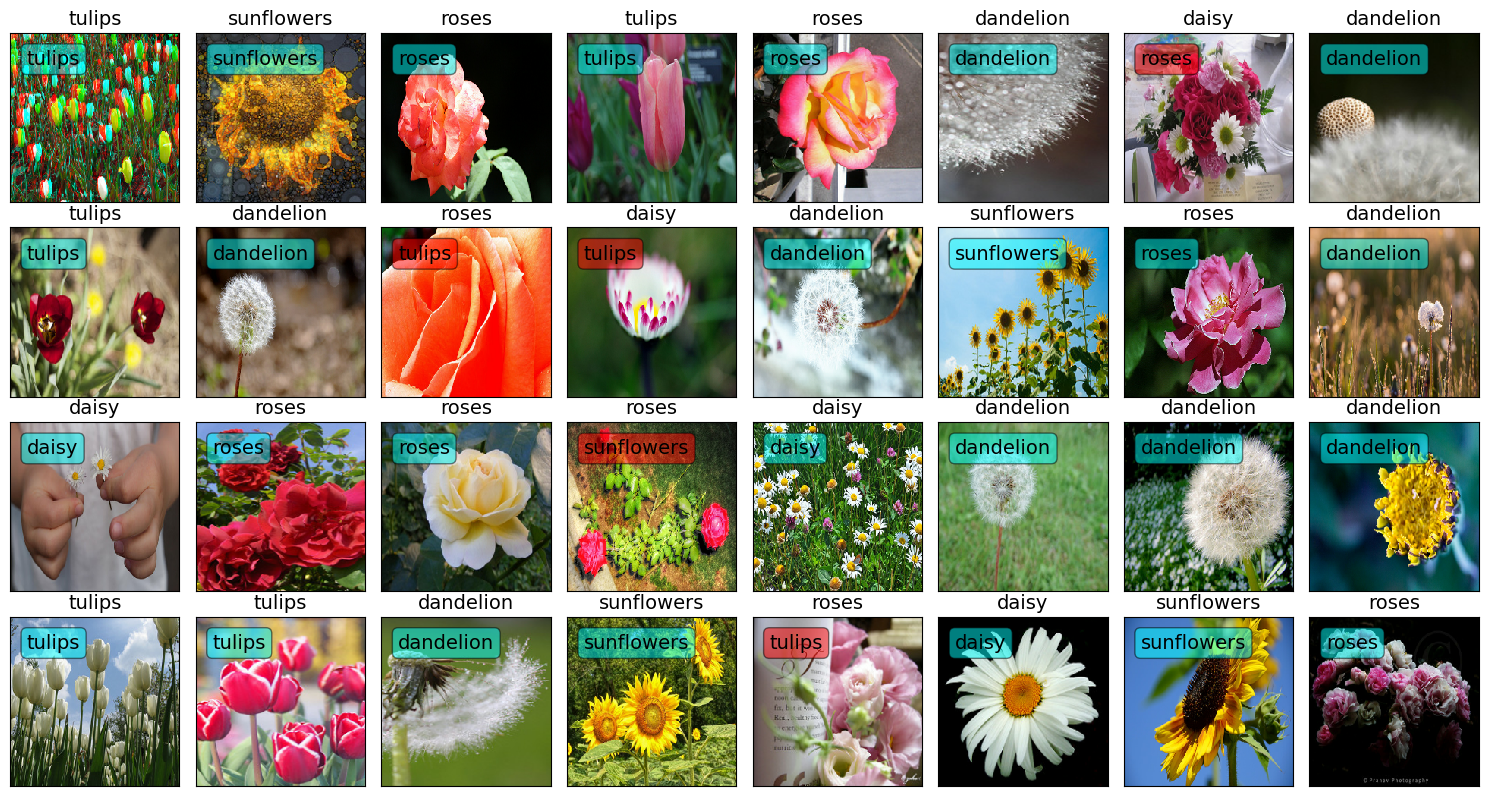

In [59]:
fig = plt.figure()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

i=0
for images, labels in test_ds.take(1):
    yhat = model(images).numpy()
    y_pred = yhat.argmax(axis=1)
    for i in range(BATCH_SIZE):
        ax = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[])
        ax.grid(False)
        color = 'cyan'
        if y_pred[i] != labels[i]:
            color = 'red'
        props = dict(boxstyle = 'round',facecolor = color,alpha = 0.5)
        ax.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary, interpolation='nearest')
        # ax.text(2,4, str(labels[i].numpy()), color='b', fontsize=14)
        # ax.text(10,25, class_names[labels[i].numpy()], color='r', fontsize=10)
        ax.text(0.1,0.90,class_names[y_pred[i]],bbox = props,
               verticalalignment = 'top',
               transform = ax.transAxes,fontsize = 14)
        ax.set_title(class_names[labels[i].numpy()],fontsize = 14)
plt.tight_layout()
plt.show()